# Problem Statement

The Indian Premier League (IPL) is one of the world's most popular and fast-paced T20 cricket leagues, generating a massive amount of ball-by-ball data every season. Analyzing player performances, team strategies, match outcomes, and venue influences can be challenging due to the complexity and volume of the data.

This project performs **Exploratory Data Analysis (EDA)** on **IPL ball-by-ball data from 2008 to 2024** to examine **batting performance, bowling effectiveness, match outcomes, and venue impact.** By using Python and data visualization techniques, the project aims to uncover valuable insights and performance trends across IPL seasons.
# ________________________________________________________________________________________

# Dataset Information

The IPL dataset contains detailed information about IPL matches and ball-by-ball deliveries from 2008 to 2024. It includes match details, team performances, player statistics, batting and bowling records, and match outcomes.

## Match Information

- **ID:** Unique identifier for each match.
- **Season:** IPL season in which the match was played.
- **City:** City where the match was held.
- **Date:** Date on which the match was played.
- **Venue:** Stadium where the match was played.
- **Match Type:** Type of match played.
- **Team1:** First competing team.
- **Team2:** Second competing team.
- **Winner:** Team that won the match.
- **Player of Match:** Player receiving the Player of the Match award.

## Toss Information

- **Toss Winner:** Team that won the toss.
- **Toss Decision:** Decision taken after winning the toss (bat or field).

## Ball-by-Ball Information

- **Match ID:** Unique identifier linking each delivery to a match.
- **Inning:** Innings number (1 or 2).
- **Over:** Over number within the innings.
- **Ball:** Ball number within the over.

## Player Information

- **Batter:** Batter facing the delivery.
- **Non Striker:** Non-striking batter.
- **Bowler:** Bowler delivering the ball.

## Runs Information

- **Batsman Runs:** Runs scored by the batter.
- **Extra Runs:** Runs awarded as extras.
- **Total Runs:** Total runs scored from the delivery.

## Wicket Information

- **Is Wicket:** Indicates whether a wicket fell on the delivery.
- **Player Dismissed:** Name of the dismissed player.
- **Dismissal Kind:** Type of dismissal.
- **Fielder:** Fielder involved in the dismissal.

## Match Result Information

- **Result:** Match result status.
- **Result Margin:** Winning margin.
- **Target Runs:** Target score in the second innings.
- **Target Overs:** Overs available to chase the target.
- **Super Over:** Indicates whether the match involved a Super Over.
- **Method:** Match result method (including DLS method, if applicable).
#  ________________________________________________________________________________________

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

%matplotlib inline

# Load Data

In [4]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# Dataset Overview & Structure

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [7]:
print("Matches Dataset Shape:", matches.shape)

Matches Dataset Shape: (1095, 20)


In [8]:
print("Deliveries Dataset Shape:", deliveries.shape)

Deliveries Dataset Shape: (260920, 17)


# Identifying Key Columns and Understanding Data Types

In [9]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')

In [10]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

In [11]:
matches.dtypes

id                   int64
season                 str
city                   str
date                   str
match_type             str
player_of_match        str
venue                  str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
winner                 str
result                 str
result_margin      float64
target_runs        float64
target_overs       float64
super_over             str
method                 str
umpire1                str
umpire2                str
dtype: object

In [12]:
deliveries.dtypes

match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          int64
extras_type           str
is_wicket           int64
player_dismissed      str
dismissal_kind        str
fielder               str
dtype: object

In [13]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [14]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

# Data Cleaning

Data cleaning is an essential step in Exploratory Data Analysis (EDA). It helps identify missing values, duplicate records, inconsistent data, and incorrect data types that may affect the analysis.

## Standardizing Categorical Data

Before moving to analysis, it is important to ensure consistency in categorical values. Standardizing team names, venue names, and other categorical variables helps prevent errors during grouping, filtering, and aggregation operations.

In [15]:
categorical_columns = matches.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'super_over', 'method', 'umpire1', 'umpire2']


In [16]:
categorical_columns = deliveries.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)

['batting_team', 'bowling_team', 'batter', 'bowler', 'non_striker', 'extras_type', 'player_dismissed', 'dismissal_kind', 'fielder']


## Cleaning Venue Names

In [17]:
matches['venue'].unique()

<ArrowStringArray>
[                                                'M Chinnaswamy Stadium',
                            'Punjab Cricket Association Stadium, Mohali',
                                                      'Feroz Shah Kotla',
                                                      'Wankhede Stadium',
                                                          'Eden Gardens',
                                                'Sawai Mansingh Stadium',
                             'Rajiv Gandhi International Stadium, Uppal',
                                       'MA Chidambaram Stadium, Chepauk',
                                            'Dr DY Patil Sports Academy',
                                                              'Newlands',
                                                      'St George's Park',
                                                             'Kingsmead',
                                                       'SuperSport Park',
                   

In [18]:
# Standardizing Venue Names

venue_map = {
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Sardar Patel Stadium": "Narendra Modi Stadium",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",
    "De Beers Diamond Oval": "Kimberley Oval",
    "Rajiv Gandhi International Stadium": "Uppal Stadium",
    "Dr Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "ACA-VDCA Stadium",
    "Shaheed Veer Narayan Singh International Stadium": "Raipur International Cricket Stadium",
    "JSCA International Stadium Complex": "Ranchi Stadium",
    "Barsapara Cricket Stadium": "Assam Cricket Association Stadium"
}

matches["venue"] = matches["venue"].replace(venue_map)

## Cleaning Team Names

In [19]:
matches['team1'].unique()

<ArrowStringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [20]:
matches['team2'].unique()

<ArrowStringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Rajasthan Royals', 'Royal Challengers Bangalore',
             'Deccan Chargers',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
              'Gujarat Titans',        'Lucknow Super Giants',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [21]:
matches['winner'].unique()

<ArrowStringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Delhi Daredevils', 'Royal Challengers Bangalore',
            'Rajasthan Royals',             'Kings XI Punjab',
             'Deccan Chargers',              'Mumbai Indians',
               'Pune Warriors',        'Kochi Tuskers Kerala',
                           nan,         'Sunrisers Hyderabad',
     'Rising Pune Supergiants',               'Gujarat Lions',
      'Rising Pune Supergiant',              'Delhi Capitals',
                'Punjab Kings',              'Gujarat Titans',
        'Lucknow Super Giants', 'Royal Challengers Bengaluru']
Length: 20, dtype: str

In [22]:
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}

matches["team1"] = matches["team1"].replace(team_name_map)
matches["team2"] = matches["team2"].replace(team_name_map)
matches["winner"] = matches["winner"].replace(team_name_map)
matches["toss_winner"] = matches["toss_winner"].replace(team_name_map)

In [23]:
matches['team1'].unique()

<ArrowStringArray>
['Royal Challengers Bangalore',                'Punjab Kings',
              'Delhi Capitals',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 17, dtype: str

## Cleaning Player Names

In [24]:
deliveries["batter"] = deliveries["batter"].str.strip().str.title()
deliveries["non_striker"] = deliveries["non_striker"].str.strip().str.title()
deliveries["bowler"] = deliveries["bowler"].str.strip().str.title()
deliveries["player_dismissed"] = deliveries["player_dismissed"].str.strip().str.title()

# Handling Missing & Duplicated Data

## Identifying Missing values

In [25]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [26]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

### Observations:

- The **city** column contains **51 missing values**, indicating that the city information was unavailable for some matches.
- The **player_of_match** and **winner** columns contain **5 missing values each**, which correspond to matches with no result.
- The **result_margin** column has **19 missing values** due to tied or abandoned matches.
- The **target_runs** and **target_overs** columns contain **3 missing values**, primarily because these values are not applicable in certain match situations.
- The **method** column contains **1,074 missing values** because only a few matches were decided using the Duckworth-Lewis-Stern (DLS) method.
- The **extras_type** column has **2,46,795 missing values** since most deliveries do not result in extras.
- The **player_dismissed**, **dismissal_kind**, and **fielder** columns contain **many missing values** because wickets do not occur on every delivery.
- No significant duplicate records were found in the datasets.
- Overall, the missing values are meaningful and do not indicate data quality issues. The datasets are suitable for further exploratory data analysis.

In [27]:
matches['city'].fillna('Unknown', inplace=True)

matches['winner'].fillna('No Result', inplace=True)

matches['player_of_match'].fillna('Not Awarded', inplace=True)

0           BB McCullum
1            MEK Hussey
2           MF Maharoof
3            MV Boucher
4             DJ Hussey
             ...       
1090    Abhishek Sharma
1091           MA Starc
1092           R Ashwin
1093      Shahbaz Ahmed
1094           MA Starc
Name: player_of_match, Length: 1095, dtype: str

In [28]:
deliveries['dismissal_kind'].fillna('Not Applicable', inplace=True)

deliveries['player_dismissed'].fillna('Not Out', inplace=True)

deliveries['fielder'].fillna('No Fielder', inplace=True)

deliveries['extras_type'].fillna('No Extra', inplace=True)

0          legbyes
1         No Extra
2            wides
3         No Extra
4         No Extra
            ...   
260915    No Extra
260916    No Extra
260917    No Extra
260918    No Extra
260919    No Extra
Name: extras_type, Length: 260920, dtype: str

### Check for Duplicates

In [29]:
matches.duplicated().sum()

np.int64(0)

No Duplicates found

In [30]:
deliveries.duplicated().sum()

np.int64(0)

No Duplicates found

### Data Type Corrections

- **date** was converted from **object** to **datetime64** for time-based analysis.
- Categorical columns were converted to **category** to improve memory efficiency.
- **is_wicket** was converted from **int64** to **bool** as it contains binary values.
- Data types were optimized to improve analysis performance and reduce memory usage.

In [31]:
# Convert date to datetime format
matches['date'] = pd.to_datetime(matches['date'])

# Convert categorical columns
matches['match_type'] = matches['match_type'].astype('category')
matches['toss_decision'] = matches['toss_decision'].astype('category')
matches['result'] = matches['result'].astype('category')

deliveries['batting_team'] = deliveries['batting_team'].astype('category')
deliveries['bowling_team'] = deliveries['bowling_team'].astype('category')
deliveries['extras_type'] = deliveries['extras_type'].astype('category')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].astype('category')

# Convert is_wicket to boolean
deliveries['is_wicket'] = deliveries['is_wicket'].astype(bool)

# Feature Engineering

In [32]:
# Extract year from date

matches['year'] = matches['date'].dt.year

In [33]:
# Create six indicator

deliveries['is_six'] = (deliveries['batsman_runs'] == 6).astype(int)

In [34]:
# Create four indicator

deliveries['is_four'] = (deliveries['batsman_runs'] == 4).astype(int)

In [35]:
# Create dot ball indicator

deliveries['is_dot_ball'] = (
    (deliveries['total_runs'] == 0)
).astype(int)

In [36]:
# Create bowler wicket indicator

valid_wickets = ['bowled', 'caught', 'lbw',
                 'stumped', 'caught and bowled',
                 'hit wicket']

deliveries['bowler_wicket'] = (
    deliveries['dismissal_kind']
    .isin(valid_wickets)
    .astype(int)
)

# EDA

## 1.Who scored the highest total runs in each IPL season (Orange Cap winners)?

In [39]:
# Merge season information into deliveries
ipl = deliveries.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)

# Total runs scored by each batter in each season
batter_yearly_runs = (
    ipl.groupby(['season', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

# Find Orange Cap winners
orange_cap_winners = batter_yearly_runs.loc[
    batter_yearly_runs.groupby('season')['batsman_runs'].idxmax()
]

# Rename columns
orange_cap_winners = orange_cap_winners.rename(
    columns={
        'season': 'Season',
        'batter': 'Batter',
        'batsman_runs': 'Total Runs in Season'
    }
)

# Sort by season
orange_cap_winners = orange_cap_winners.sort_values('Season')

# Display results
orange_cap_winners

,Season,Batter,Total Runs in Season
116,2007/08,Se Marsh,616
230,2009,Ml Hayden,572
446,2009/10,Sr Tendulkar,618
502,2011,Ch Gayle,608
684,2012,Ch Gayle,733
911,2013,Mek Hussey,733
1088,2014,Rv Uthappa,660
1148,2015,Da Warner,562
1383,2016,V Kohli,973
1422,2017,Da Warner,641


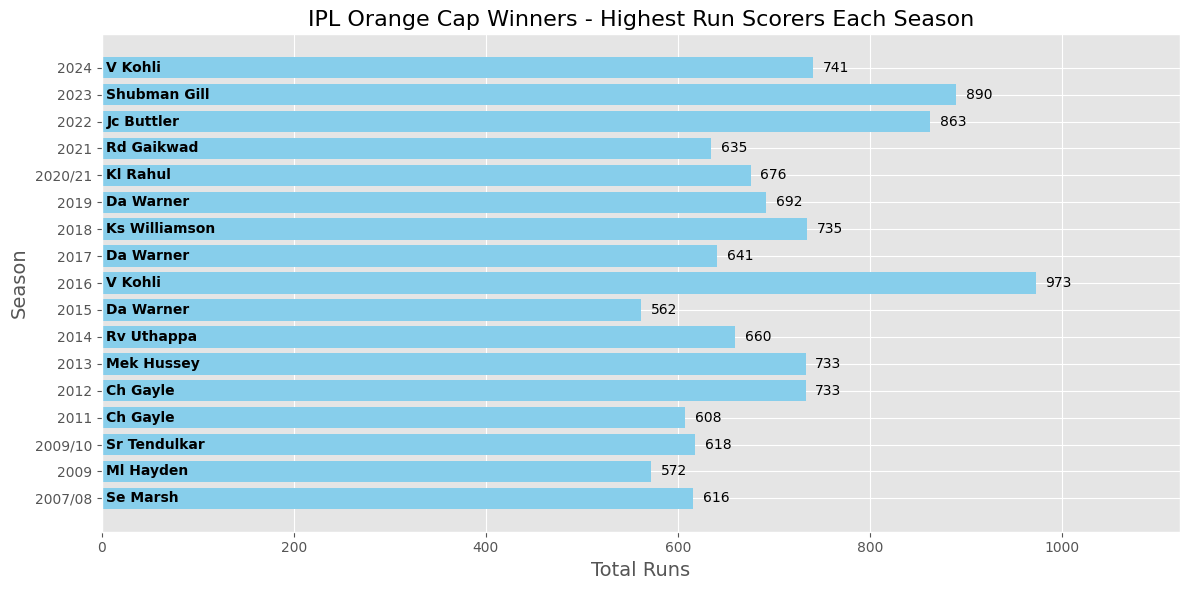

In [40]:
# Set figure size
plt.figure(figsize=(12, 6))

# Horizontal bar plot
plt.barh(
    orange_cap_winners['Season'].astype(str),
    orange_cap_winners['Total Runs in Season'],
    color='skyblue'
)

# Labels and title
plt.xlabel('Total Runs', fontsize=14)
plt.ylabel('Season', fontsize=14)
plt.title(
    'IPL Orange Cap Winners - Highest Run Scorers Each Season',
    fontsize=16
)

# Add batter names and runs
for i, (season, batter, runs) in enumerate(
    zip(
        orange_cap_winners['Season'],
        orange_cap_winners['Batter'],
        orange_cap_winners['Total Runs in Season']
    )
):
    # Batter name
    plt.text(
        5, i, batter,
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    # Runs scored
    plt.text(
        runs + 10, i, str(runs),
        va='center',
        fontsize=10
    )

# Adjust x-axis limit
plt.xlim(
    0,
    orange_cap_winners['Total Runs in Season'].max() + 150
)

plt.tight_layout()
plt.show()

## 2.Which batsman hit the most sixes in each IPL season?

In [41]:
# Create six indicator
ipl['is_six'] = (ipl['batsman_runs'] == 6).astype(int)

# Count total sixes by batter in each season
batter_sixes = (
    ipl.groupby(['season', 'batter'])['is_six']
    .sum()
    .reset_index()
)

# Find the batter with the most sixes in each season
top_six_hitter_idx = (
    batter_sixes.groupby('season')['is_six']
    .idxmax()
)

# Select those rows
most_sixes_per_year = batter_sixes.loc[top_six_hitter_idx]

# Rename columns
most_sixes_per_year = most_sixes_per_year.rename(
    columns={
        'season': 'Season',
        'batter': 'Batter',
        'is_six': 'Total Sixes'
    }
)

# Sort by season
most_sixes_per_year = most_sixes_per_year.sort_values('Season')

most_sixes_per_year

,Season,Batter,Total Sixes
131,2007/08,St Jayasuriya,31
166,2009,Ac Gilchrist,29
427,2009/10,Rv Uthappa,27
502,2011,Ch Gayle,44
684,2012,Ch Gayle,59
852,2013,Ch Gayle,52
1025,2014,Gj Maxwell,36
1142,2015,Ch Gayle,38
1383,2016,V Kohli,38
1422,2017,Da Warner,26


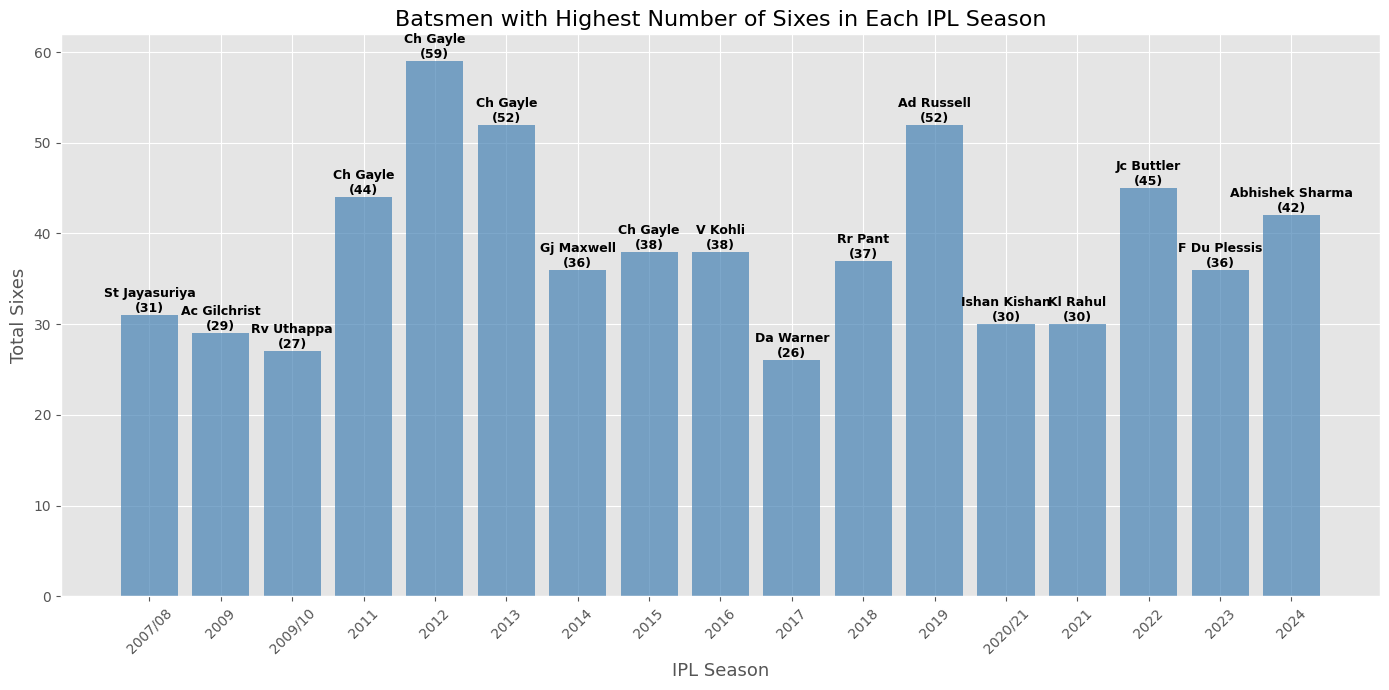

In [52]:
# Visualization
plt.figure(figsize=(14, 7))

bars = plt.bar(
    most_sixes_per_year['Season'].astype(str),
    most_sixes_per_year['Total Sixes'],
    color='steelblue',
    alpha=0.7
)

# Annotate bars with batter names and sixes
for bar, batter, sixes in zip(
    bars,
    most_sixes_per_year['Batter'],
    most_sixes_per_year['Total Sixes']
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{batter}\n({sixes})',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Labels and title
plt.xlabel('IPL Season', fontsize=13)
plt.ylabel('Total Sixes', fontsize=13)
plt.title(
    'Batsmen with Highest Number of Sixes in Each IPL Season',
    fontsize=16
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3.Who took the highest wickets in each IPL season (Purple Cap winners)?

In [45]:
# Count total wickets per bowler per season
wickets_per_year = (
    ipl.groupby(['season', 'bowler'])['bowler_wicket']
    .sum()
    .reset_index()
)

# Find the top wicket-taker in each season
top_wicket_taker_idx = (
    wickets_per_year.groupby('season')['bowler_wicket']
    .idxmax()
)

# Select the Purple Cap winners
top_wicket_takers = wickets_per_year.loc[top_wicket_taker_idx]

# Rename columns
top_wicket_takers = top_wicket_takers.rename(
    columns={
        'season': 'Season',
        'bowler': 'Bowler',
        'bowler_wicket': 'Total Wickets'
    }
)

# Sort by season
top_wicket_takers = top_wicket_takers.sort_values('Season')

top_wicket_takers

,Season,Bowler,Total Wickets
82,2007/08,Sohail Tanvir,22
174,2009,Rp Singh,23
285,2009/10,Pp Ojha,21
448,2011,Sl Malinga,28
538,2012,M Morkel,25
629,2013,Dj Bravo,32
779,2014,Mm Sharma,23
847,2015,Dj Bravo,26
938,2016,B Kumar,23
1048,2017,B Kumar,26


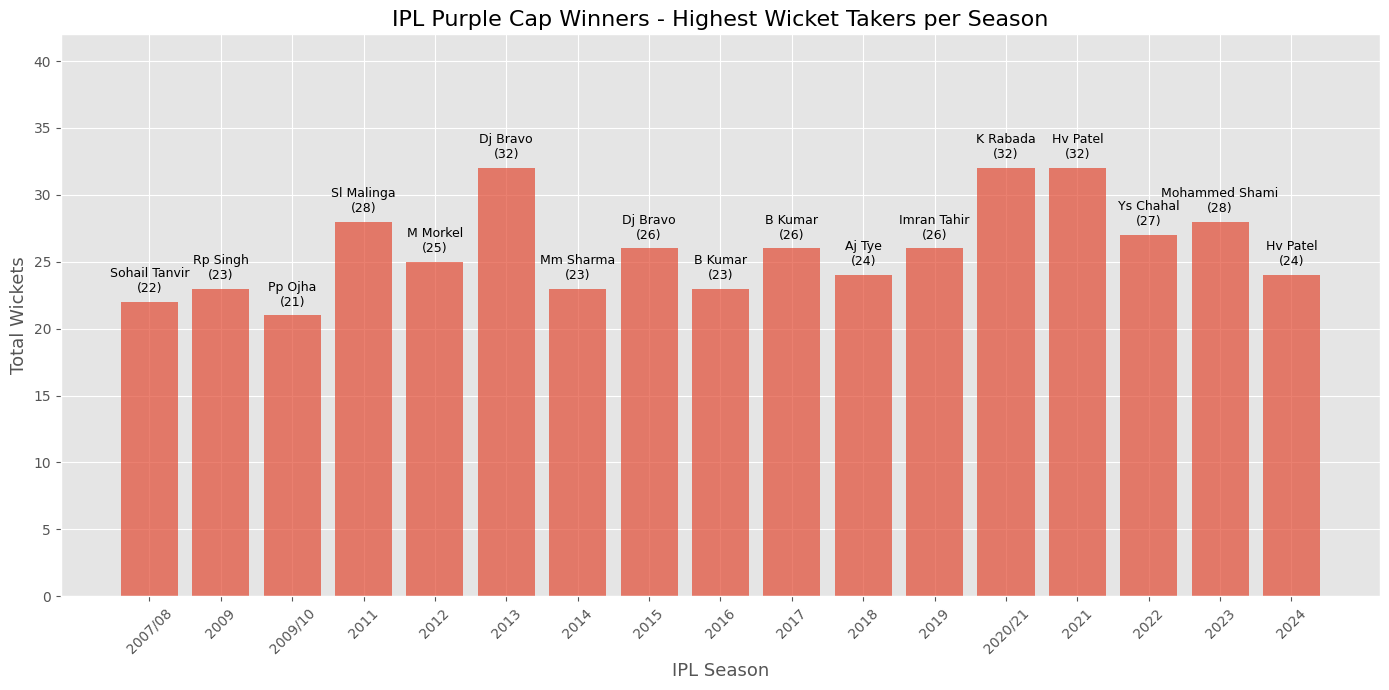

In [46]:
# Visualization
plt.figure(figsize=(14, 7))

bars = plt.bar(
    top_wicket_takers['Season'].astype(str),
    top_wicket_takers['Total Wickets'],
    alpha=0.7
)

# Add annotations
for bar, bowler, wickets in zip(
    bars,
    top_wicket_takers['Bowler'],
    top_wicket_takers['Total Wickets']
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bowler}\n({wickets})',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Labels and title
plt.xlabel('IPL Season', fontsize=13)
plt.ylabel('Total Wickets', fontsize=13)
plt.title(
    'IPL Purple Cap Winners - Highest Wicket Takers per Season',
    fontsize=16
)

plt.xticks(rotation=45)
plt.ylim(0, top_wicket_takers['Total Wickets'].max() + 10)

plt.tight_layout()
plt.show()

## 4.Which bowler delivered the highest number of dot balls in each IPL season?

In [48]:
ipl['is_dot_ball'] = (ipl['total_runs'] == 0).astype(int)

In [49]:
dot_balls_per_bowler = (
    ipl.groupby(['season', 'bowler'])['is_dot_ball']
    .sum()
    .reset_index()
)

In [50]:
top_dot_bowlers_idx = (
    dot_balls_per_bowler.groupby('season')['is_dot_ball']
    .idxmax()
)

top_dot_bowlers = dot_balls_per_bowler.loc[top_dot_bowlers_idx]

top_dot_bowlers = top_dot_bowlers.rename(
    columns={
        'season': 'Season',
        'bowler': 'Bowler',
        'is_dot_ball': 'Total Dot Balls'
    }
)

top_dot_bowlers = top_dot_bowlers.sort_values('Season')

top_dot_bowlers

,Season,Bowler,Total Dot Balls
83,2007/08,Sr Watson,158
174,2009,Rp Singh,169
244,2009/10,Dw Steyn,164
448,2011,Sl Malinga,183
546,2012,P Kumar,168
636,2013,Dw Steyn,211
733,2014,Ar Patel,157
830,2015,A Nehra,170
938,2016,B Kumar,156
1123,2017,Sp Narine,133


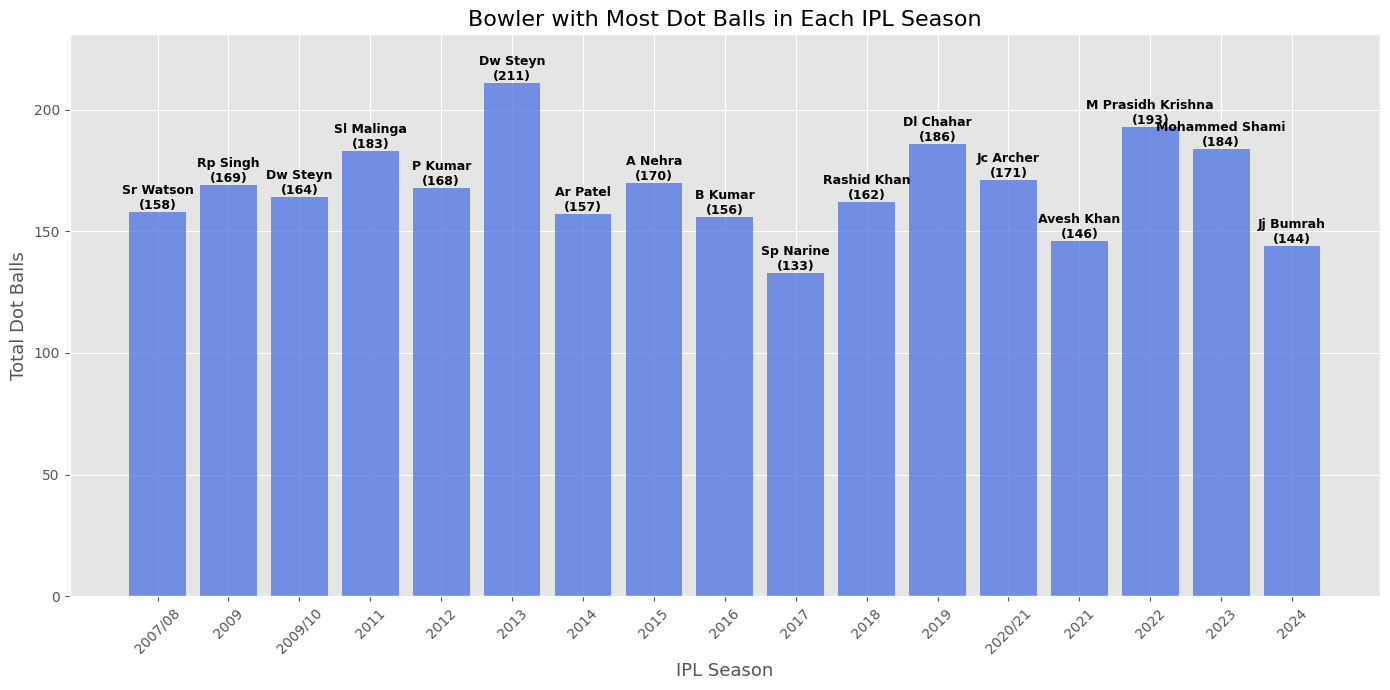

In [51]:
# Visualization
plt.figure(figsize=(14, 7))

bars = plt.bar(
    top_dot_bowlers['Season'].astype(str),
    top_dot_bowlers['Total Dot Balls'],
    color='royalblue',
    alpha=0.7
)

# Add annotations
for bar, bowler, dots in zip(
    bars,
    top_dot_bowlers['Bowler'],
    top_dot_bowlers['Total Dot Balls']
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bowler}\n({dots})',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Labels and title
plt.xlabel('IPL Season', fontsize=13)
plt.ylabel('Total Dot Balls', fontsize=13)
plt.title(
    'Bowler with Most Dot Balls in Each IPL Season',
    fontsize=16
)

plt.xticks(rotation=45)
plt.ylim(0, top_dot_bowlers['Total Dot Balls'].max() + 20)

plt.tight_layout()
plt.show()

## 5.What was the highest target set in each IPL season?

In [53]:
# Highest target in each IPL season
highest_target_per_season = (
    matches.groupby('season')['target_runs']
    .max()
    .reset_index()
)

# Rename columns
highest_target_per_season = highest_target_per_season.rename(
    columns={
        'season': 'Season',
        'target_runs': 'Highest Target'
    }
)

highest_target_per_season

,Season,Highest Target
0,2007/08,241.0
1,2009,212.0
2,2009/10,247.0
3,2011,233.0
4,2012,223.0
5,2013,264.0
6,2014,232.0
7,2015,236.0
8,2016,249.0
9,2017,231.0


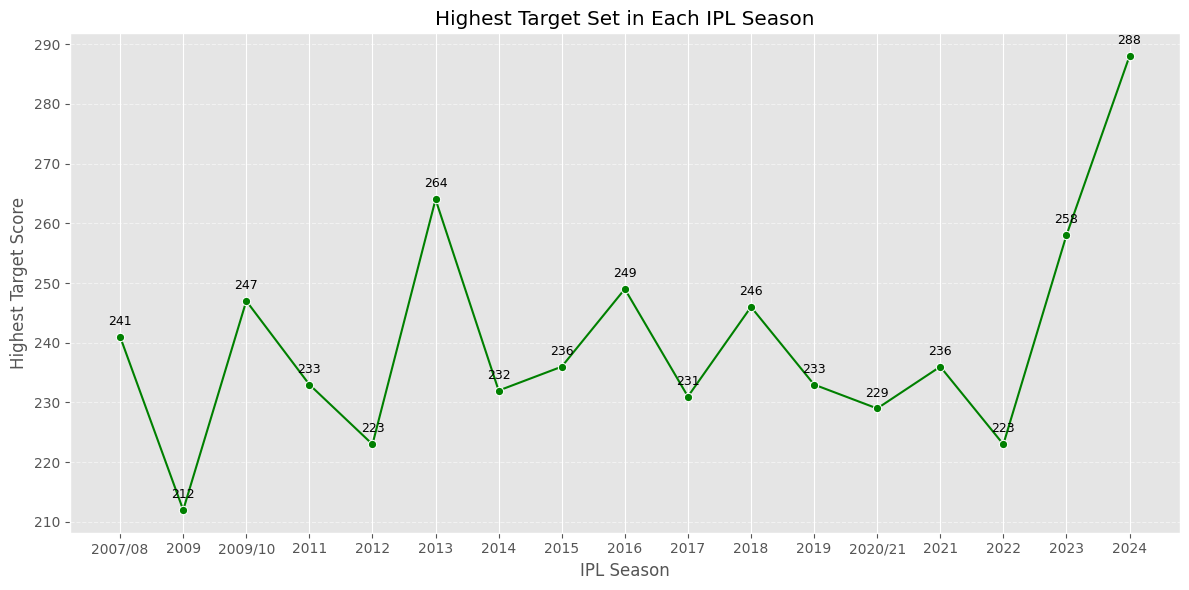

In [54]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=highest_target_per_season,
    x='Season',
    y='Highest Target',
    marker='o',
    color='green'
)

# Add target values on points
for x, y in zip(
    highest_target_per_season['Season'],
    highest_target_per_season['Highest Target']
):
    plt.text(x, y + 2, int(y),
             ha='center',
             fontsize=9)

plt.xlabel('IPL Season')
plt.ylabel('Highest Target Score')
plt.title('Highest Target Set in Each IPL Season')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6.What was the lowest target set in each IPL season?

In [55]:
# Lowest target in each IPL season
lowest_target_per_season = (
    matches.groupby('season')['target_runs']
    .min()
    .reset_index()
)

# Rename columns
lowest_target_per_season = lowest_target_per_season.rename(
    columns={
        'season': 'Season',
        'target_runs': 'Lowest Target'
    }
)

lowest_target_per_season

,Season,Lowest Target
0,2007/08,53.0
1,2009,54.0
2,2009/10,83.0
3,2011,52.0
4,2012,93.0
5,2013,81.0
6,2014,43.0
7,2015,81.0
8,2016,58.0
9,2017,48.0


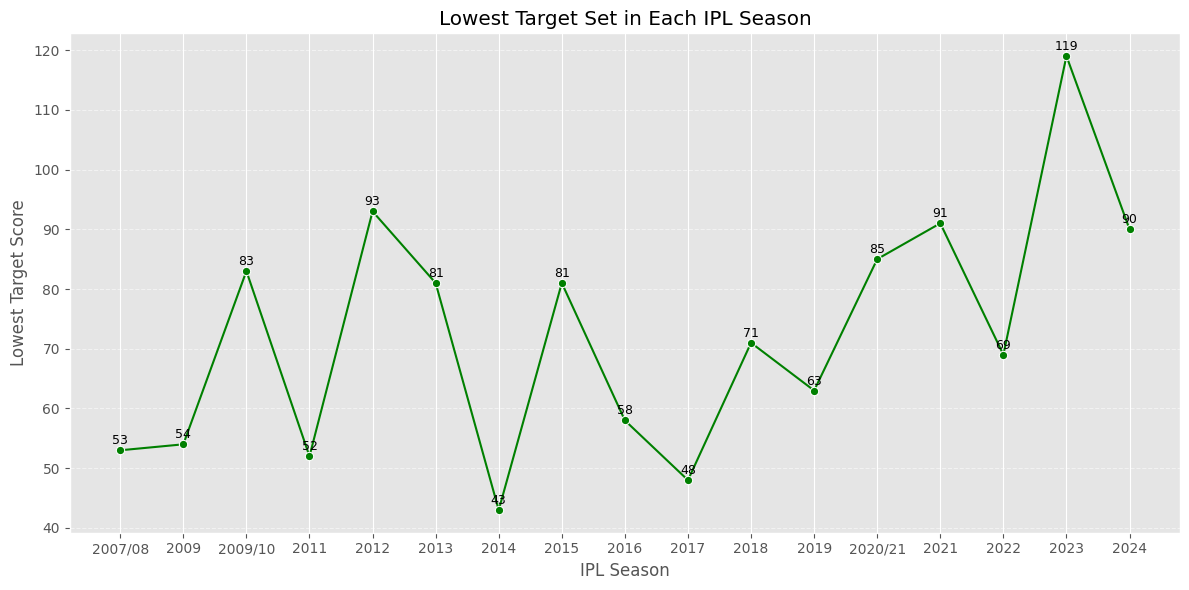

In [56]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=lowest_target_per_season,
    x='Season',
    y='Lowest Target',
    marker='o',
    color='green'
)

# Add values on each point
for x, y in zip(
    lowest_target_per_season['Season'],
    lowest_target_per_season['Lowest Target']
):
    plt.text(
        x, y + 1,
        int(y),
        ha='center',
        fontsize=9
    )

plt.xlabel('IPL Season')
plt.ylabel('Lowest Target Score')
plt.title('Lowest Target Set in Each IPL Season')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7.Count of IPL titles won by each team?

In [57]:
# Find the final match of each season
final_matches = matches.groupby('season')['id'].max().reset_index()

# Get the winners of those final matches
final_winners = matches[
    matches['id'].isin(final_matches['id'])
][['season', 'winner']]

# Count IPL titles
winner_count = (
    final_winners['winner']
    .value_counts()
    .reset_index()
)

winner_count.columns = ['Team', 'Titles Won']

winner_count

,Team,Titles Won
0,Chennai Super Kings,5
1,Mumbai Indians,5
2,Kolkata Knight Riders,3
3,Rajasthan Royals,1
4,Deccan Chargers,1
5,Sunrisers Hyderabad,1
6,Gujarat Titans,1


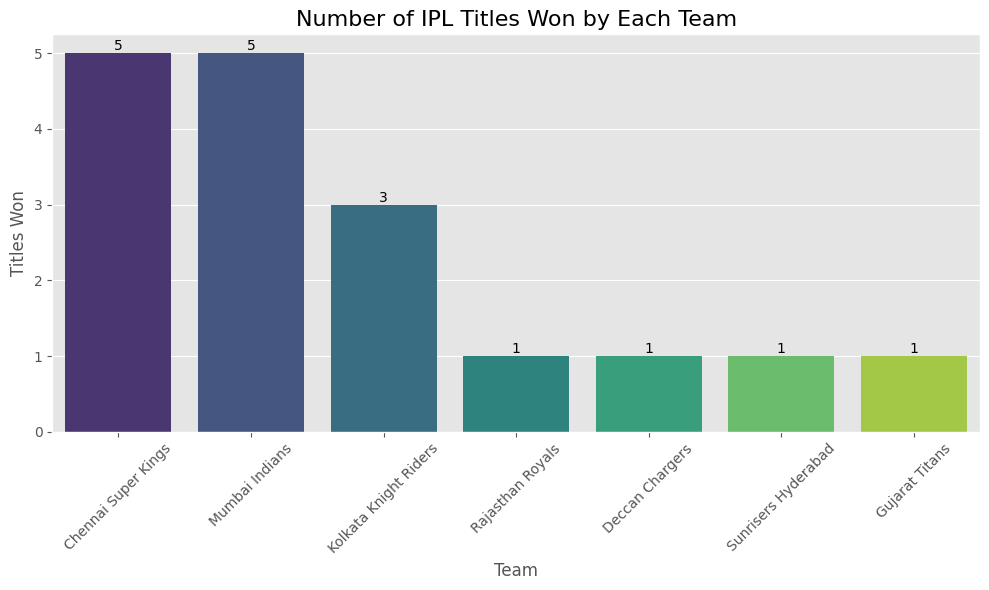

In [58]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Team',
    y='Titles Won',
    data=winner_count,
    palette='viridis'
)

# Add title counts on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title('Number of IPL Titles Won by Each Team', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Titles Won', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8.Overall Win Percentage of Batting First and Chasing Teams

In [59]:
# Team batting first
matches['bat_first'] = np.where(
    matches['toss_decision'] == 'bat',
    matches['toss_winner'],
    np.where(
        matches['toss_winner'] == matches['team1'],
        matches['team2'],
        matches['team1']
    )
)

# Team batting second
matches['bat_second'] = np.where(
    matches['bat_first'] == matches['team1'],
    matches['team2'],
    matches['team1']
)

# Determine chase success
matches['chased_successfully'] = (
    matches['winner'] == matches['bat_second']
).astype(int)

In [60]:
win_counts = (
    matches['chased_successfully']
    .value_counts()
    .reset_index()
)

win_counts.columns = ['Chasing Win', 'Win Count']

win_counts['Result'] = win_counts['Chasing Win'].replace({
    0: 'Batting First Wins',
    1: 'Chasing Wins'
})

win_counts

,Chasing Win,Win Count,Result
0,1,590,Chasing Wins
1,0,505,Batting First Wins


In [61]:
win_counts['Win Percentage'] = (
    win_counts['Win Count'] /
    win_counts['Win Count'].sum()
) * 100

win_counts

,Chasing Win,Win Count,Result,Win Percentage
0,1,590,Chasing Wins,53.881279
1,0,505,Batting First Wins,46.118721


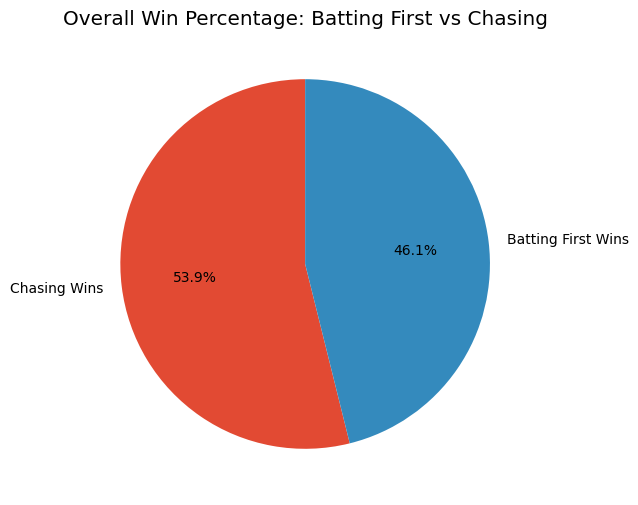

In [65]:
plt.figure(figsize=(8,6))

plt.pie(
    win_counts['Win Percentage'],
    labels=win_counts['Result'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Overall Win Percentage: Batting First vs Chasing'
)

plt.show()

## 9.Which Player Scored the Fastest Fifty in Each Season?

In [67]:
# Calculate cumulative runs for each batter in each match
ipl['Cumulative Runs'] = (
    ipl.groupby(['match_id', 'batter'])['batsman_runs']
    .cumsum()
)

# Calculate balls faced by each batter
ipl['Balls Faced'] = (
    ipl.groupby(['match_id', 'batter'])
    .cumcount() + 1
)

# Filter deliveries where the batter reaches 50 runs
fifties = ipl[ipl['Cumulative Runs'] >= 50]

# Find the fastest fifty in each season
fastest_fifties = fifties.loc[
    fifties.groupby('season')['Balls Faced'].idxmin(),
    ['season', 'batter', 'Balls Faced']
]

# Rename columns
fastest_fifties.columns = [
    'Season',
    'Player',
    'Balls Taken for Fifty'
]

# Convert season to string
fastest_fifties['Season'] = (
    fastest_fifties['Season'].astype(str)
)

fastest_fifties

,Season,Player,Balls Taken for Fifty
2050,2007/08,Yk Pathan,22
26527,2009,Ac Gilchrist,18
28793,2009/10,Rv Uthappa,19
43627,2011,Pc Valthaty,24
62942,2012,Oa Shah,20
83392,2013,Ch Gayle,17
107436,2014,Yk Pathan,15
116600,2015,Da Warner,20
127871,2016,Ch Morris,17
147157,2017,Sp Narine,17


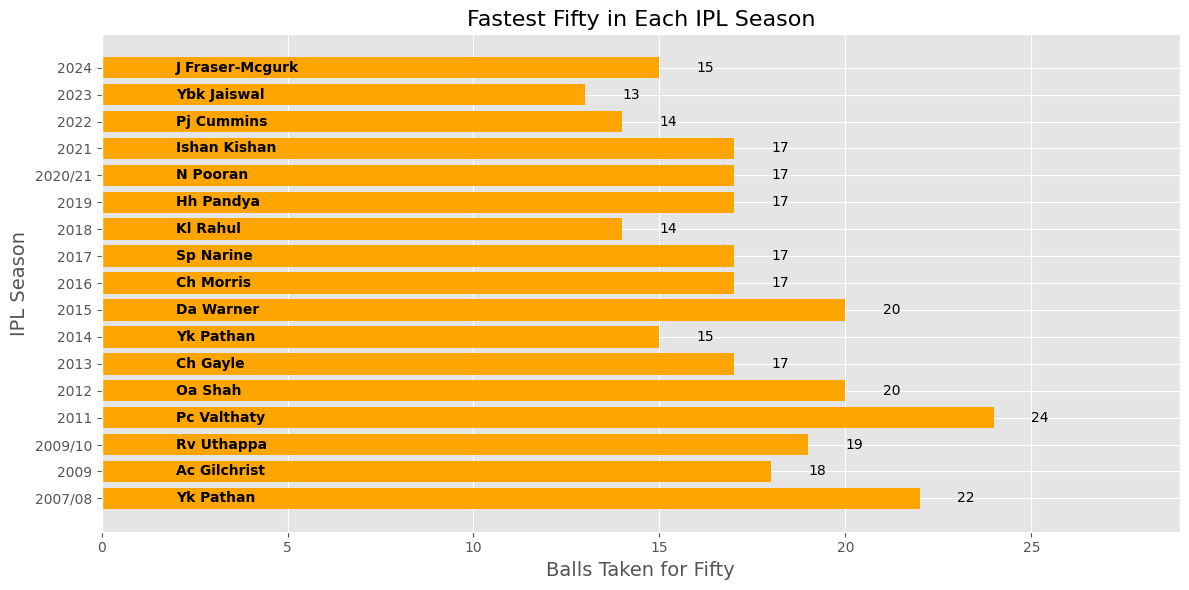

In [69]:
# Plot the fastest fifties
plt.figure(figsize=(12, 6))

plt.barh(
    fastest_fifties['Season'],
    fastest_fifties['Balls Taken for Fifty'],
    color='orange'
)

# Labels and title
plt.xlabel('Balls Taken for Fifty', fontsize=14)
plt.ylabel('IPL Season', fontsize=14)
plt.title('Fastest Fifty in Each IPL Season', fontsize=16)

# Add player names and balls taken
for i, (season, player, balls) in enumerate(
    zip(
        fastest_fifties['Season'],
        fastest_fifties['Player'],
        fastest_fifties['Balls Taken for Fifty']
    )
):
    # Player name
    plt.text(
        2, i, player,
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

    # Balls taken
    plt.text(
        balls + 1, i, str(balls),
        va='center',
        ha='left',
        fontsize=10
    )

# Set x-axis limit
plt.xlim(
    0,
    fastest_fifties['Balls Taken for Fifty'].max() + 5
)

plt.tight_layout()
plt.show()

## 10.Which venues have hosted the most IPL matches?

In [70]:
# Count matches hosted at each venue
venue_match_counts = (
    matches.groupby('venue')['id']
    .nunique()
    .reset_index()
    .rename(columns={
        'venue': 'Venue',
        'id': 'Total Matches'
    })
    .sort_values(
        'Total Matches',
        ascending=False
    )
)

venue_match_counts

,Venue,Total Matches
21,M Chinnaswamy Stadium,80
13,Eden Gardens,77
0,Arun Jaitley Stadium,74
53,Wankhede Stadium,73
39,"Rajiv Gandhi International Stadium, Uppal",49
24,"MA Chidambaram Stadium, Chepauk",48
44,Sawai Mansingh Stadium,47
12,Dubai International Cricket Stadium,46
54,"Wankhede Stadium, Mumbai",45
37,"Punjab Cricket Association Stadium, Mohali",35


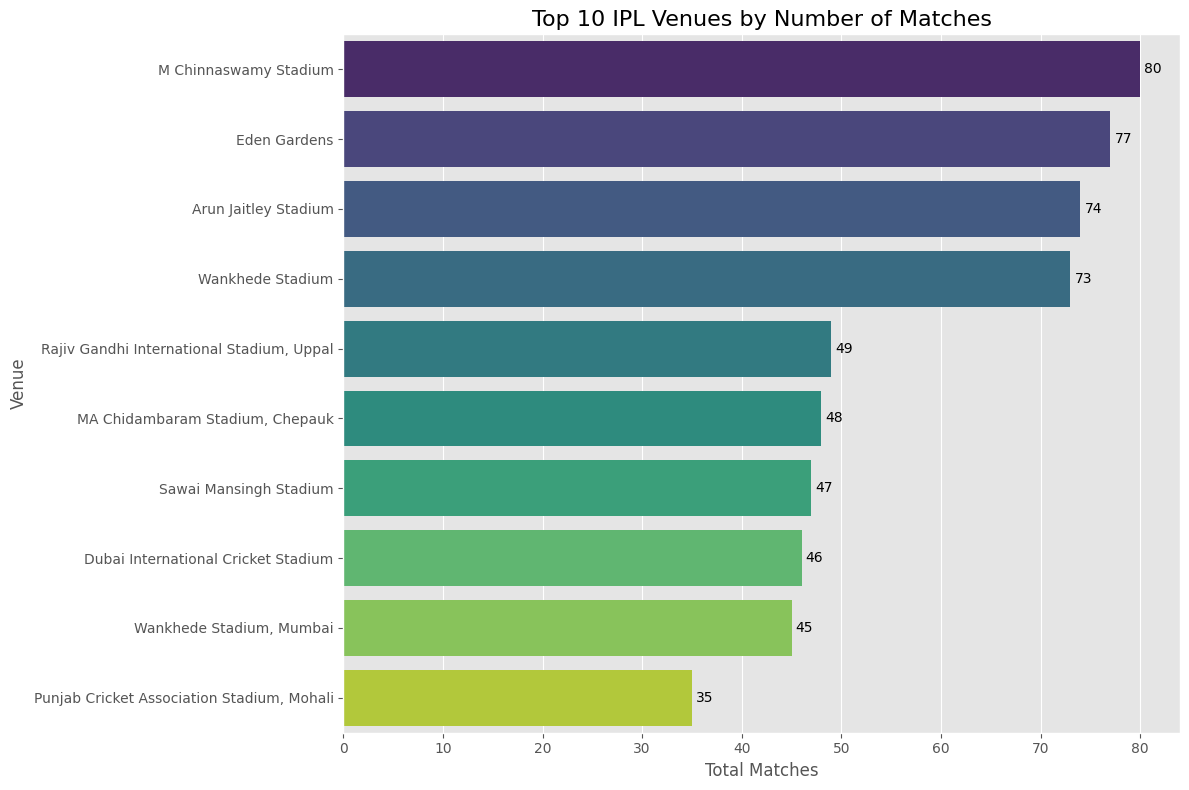

In [73]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=venue_match_counts.head(10),
    y='Venue',
    x='Total Matches',
    palette='viridis'
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel('Total Matches', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.title('Top 10 IPL Venues by Number of Matches', fontsize=16)

plt.tight_layout()
plt.show()

## 11.Does Winning the Toss Increase the Chances of Winning the Match?

In [74]:
# Create a new column to check if toss winner also won the match
matches['toss_match_win'] = (
    matches['toss_winner'] == matches['winner']
)

# Count results
toss_match_result = (
    matches['toss_match_win']
    .value_counts()
    .reset_index()
)

toss_match_result.columns = ['Toss Winner Won Match', 'Matches']

# Replace True/False with labels
toss_match_result['Toss Winner Won Match'] = (
    toss_match_result['Toss Winner Won Match']
    .replace({
        True: 'Yes',
        False: 'No'
    })
)

toss_match_result

,Toss Winner Won Match,Matches
0,Yes,554
1,No,541


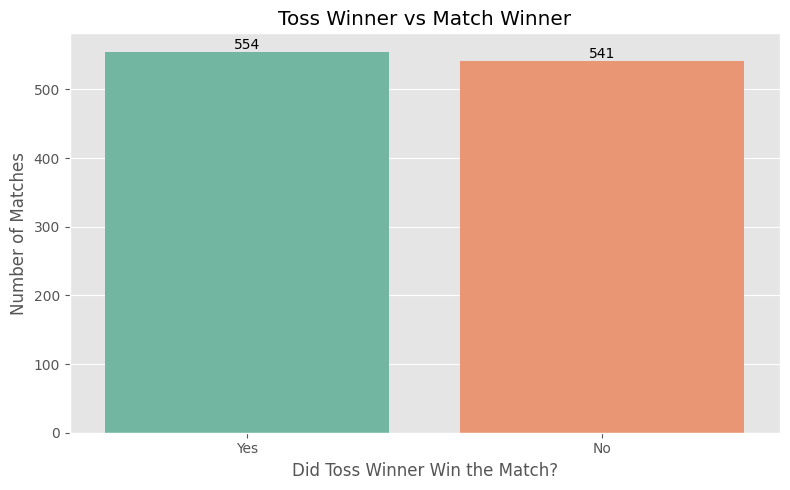

In [75]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=toss_match_result,
    x='Toss Winner Won Match',
    y='Matches',
    palette='Set2'
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Did Toss Winner Win the Match?')
plt.ylabel('Number of Matches')
plt.title('Toss Winner vs Match Winner')

plt.tight_layout()
plt.show()

## 12.Players with the Most Player of the Match Awards

In [76]:
# Count Player of the Match awards
player_awards = (
    matches['player_of_match']
    .value_counts()
    .reset_index()
)

# Rename columns
player_awards.columns = [
    'Player',
    'Player of the Match Awards'
]

# Top 10 players
top_players = player_awards.head(10)

top_players

,Player,Player of the Match Awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18
5,MS Dhoni,17
6,SR Watson,16
7,YK Pathan,16
8,RA Jadeja,16
9,SP Narine,15


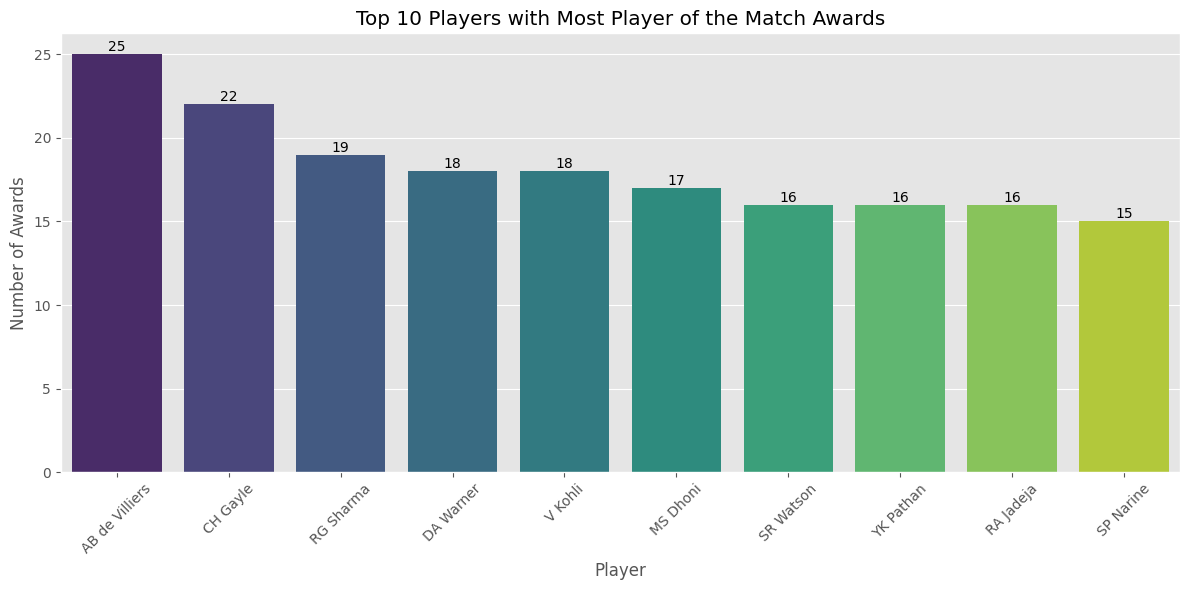

In [77]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_players,
    x='Player',
    y='Player of the Match Awards',
    palette='viridis'
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Player')
plt.ylabel('Number of Awards')
plt.title('Top 10 Players with Most Player of the Match Awards')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Key Insights

- Batting performances have become more aggressive in recent IPL seasons.
- Chasing teams have won a significant number of matches.
- Winning the toss provides some advantage but does not guarantee victory.
- Certain players and teams have consistently dominated the IPL.
- Venue conditions play an important role in match outcomes and scoring patterns.

# Conclusion

This project analyzed IPL data from 2008 to 2024 using Exploratory Data Analysis (EDA). The analysis revealed important insights into player performances, team success, match outcomes, and venue impact. Overall, the project demonstrates the effective use of Python and data visualization techniques to extract meaningful insights from sports data.